# 03 EDA

This notebook turns the cleaned NIFTY dataset into decision-ready analysis for market performance, sector comparison, liquidity, delivery strength, and trading opportunity. All return-based metrics use the processed file at `data/processed/nifty50_cleaned.csv`, and rows already flagged by the ETL as return outliers are excluded only from return calculations so that extreme anomalies do not dominate the KPI story.


In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "scripts").exists():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from scripts.eda_analysis import (
    build_analysis_artifacts,
    create_charts,
    load_cleaned_data,
    save_tables,
    summarize_dataset,
)

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")


## Load Processed Data

The notebook starts from the cleaned dataset produced by the ETL notebook. If that file is missing, the import function raises a clear dependency message instead of fabricating analysis outputs.


In [2]:
df = load_cleaned_data()
dataset_summary = summarize_dataset(df)
display(dataset_summary.to_frame("value"))

print(
    "Coverage note: the processed file contains",
    int(dataset_summary["stock_count"]),
    "stable source stocks and",
    int(dataset_summary["row_level_symbol_count"]),
    "row-level ticker spellings because some companies changed trading symbols over time."
)


,value
rows,235192
columns,35
date_start,2000-01-03
date_end,2021-04-30
stock_count,49
row_level_symbol_count,65
sector_count,13
industry_count,13
company_count,49
missing_delivery_percent_rows,16077


Coverage note: the processed file contains 49 stable source stocks and 65 row-level ticker spellings because some companies changed trading symbols over time.


## Coverage Check

Before moving into trends, we verify the historical coverage by company and sector. The metadata is complete for the committed processed file, so both company-level and sector-level analysis are available.


In [3]:
coverage_overview = pd.DataFrame(
    {
        "metric": [
            "Rows",
            "Date range start",
            "Date range end",
            "Stable stock count",
            "Row-level symbol count",
            "Sector / industry count",
        ],
        "value": [
            df.shape[0],
            df["date"].min().date().isoformat(),
            df["date"].max().date().isoformat(),
            df["source_symbol"].nunique(),
            df["symbol"].nunique(),
            df["industry"].nunique(),
        ],
    }
)
industry_counts = (
    df.groupby("industry")["source_symbol"]
    .nunique()
    .sort_values(ascending=False)
    .rename("stock_count")
    .reset_index()
)

display(coverage_overview)
display(industry_counts)


,metric,value
0,Rows,235192
1,Date range start,2000-01-03
2,Date range end,2021-04-30
3,Stable stock count,49
4,Row-level symbol count,65
5,Sector / industry count,13


,industry,stock_count
0,FINANCIAL SERVICES,9
1,ENERGY,7
2,AUTOMOBILE,6
3,CONSUMER GOODS,6
4,IT,5
5,METALS,5
6,CEMENT & CEMENT PRODUCTS,3
7,PHARMA,3
8,CONSTRUCTION,1
9,FERTILISERS & PESTICIDES,1


## Build KPI Tables and Output Artifacts

The same reusable analysis module builds the KPI tables and the chart image files. That keeps the notebook, the Tableau-ready CSVs, and the saved PNG outputs aligned.


In [4]:
artifacts = build_analysis_artifacts(df)
table_paths = save_tables(artifacts)
chart_paths = create_charts(artifacts)

for name, path in table_paths.items():
    print(f"{name}: {path}")
for name, path in chart_paths.items():
    print(f"{name}: {path}")


stock_kpis: /Users/abheydua2025/Desktop/dva-final/outputs/tables/stock_kpis.csv
sector_kpis: /Users/abheydua2025/Desktop/dva-final/outputs/tables/sector_kpis.csv
yearly_market_summary: /Users/abheydua2025/Desktop/dva-final/outputs/tables/yearly_market_summary.csv
covid_period_summary: /Users/abheydua2025/Desktop/dva-final/outputs/tables/covid_period_summary.csv
yearly_market_trend: /Users/abheydua2025/Desktop/dva-final/outputs/charts/yearly_market_trend.png
top_10_stocks_return: /Users/abheydua2025/Desktop/dva-final/outputs/charts/top_10_stocks_return.png
sector_return_comparison: /Users/abheydua2025/Desktop/dva-final/outputs/charts/sector_return_comparison.png
sector_volatility_comparison: /Users/abheydua2025/Desktop/dva-final/outputs/charts/sector_volatility_comparison.png
volume_turnover_trend: /Users/abheydua2025/Desktop/dva-final/outputs/charts/volume_turnover_trend.png
delivery_percent_trend: /Users/abheydua2025/Desktop/dva-final/outputs/charts/delivery_percent_trend.png
risk_ret

## Overall Market Trend by Year

The yearly market summary uses equal-weighted daily returns across the available company files in each session. This makes the trend easier to interpret for a broad market-comparison dashboard instead of letting the largest stocks dominate the picture.


,year,cumulative_return_percent,volatility_percent,average_turnover_cr,average_delivery_percent
0,2000,-36.43,16.59,"1,380.04",NaN
1,2001,-14.76,14.84,961.96,NaN
2,2002,-6.93,12.21,750.95,55.06
3,2003,50.54,14.64,"1,431.13",50.18
4,2004,22.56,16.14,"2,515.07",44.12
5,2005,20.04,14.28,"2,155.82",50.71
6,2006,18.38,17.47,"2,912.38",51.78
7,2007,14.78,16.62,"3,700.25",56.13
8,2008,-41.59,20.77,"4,779.24",52.05
9,2009,48.72,17.60,"5,829.49",47.85


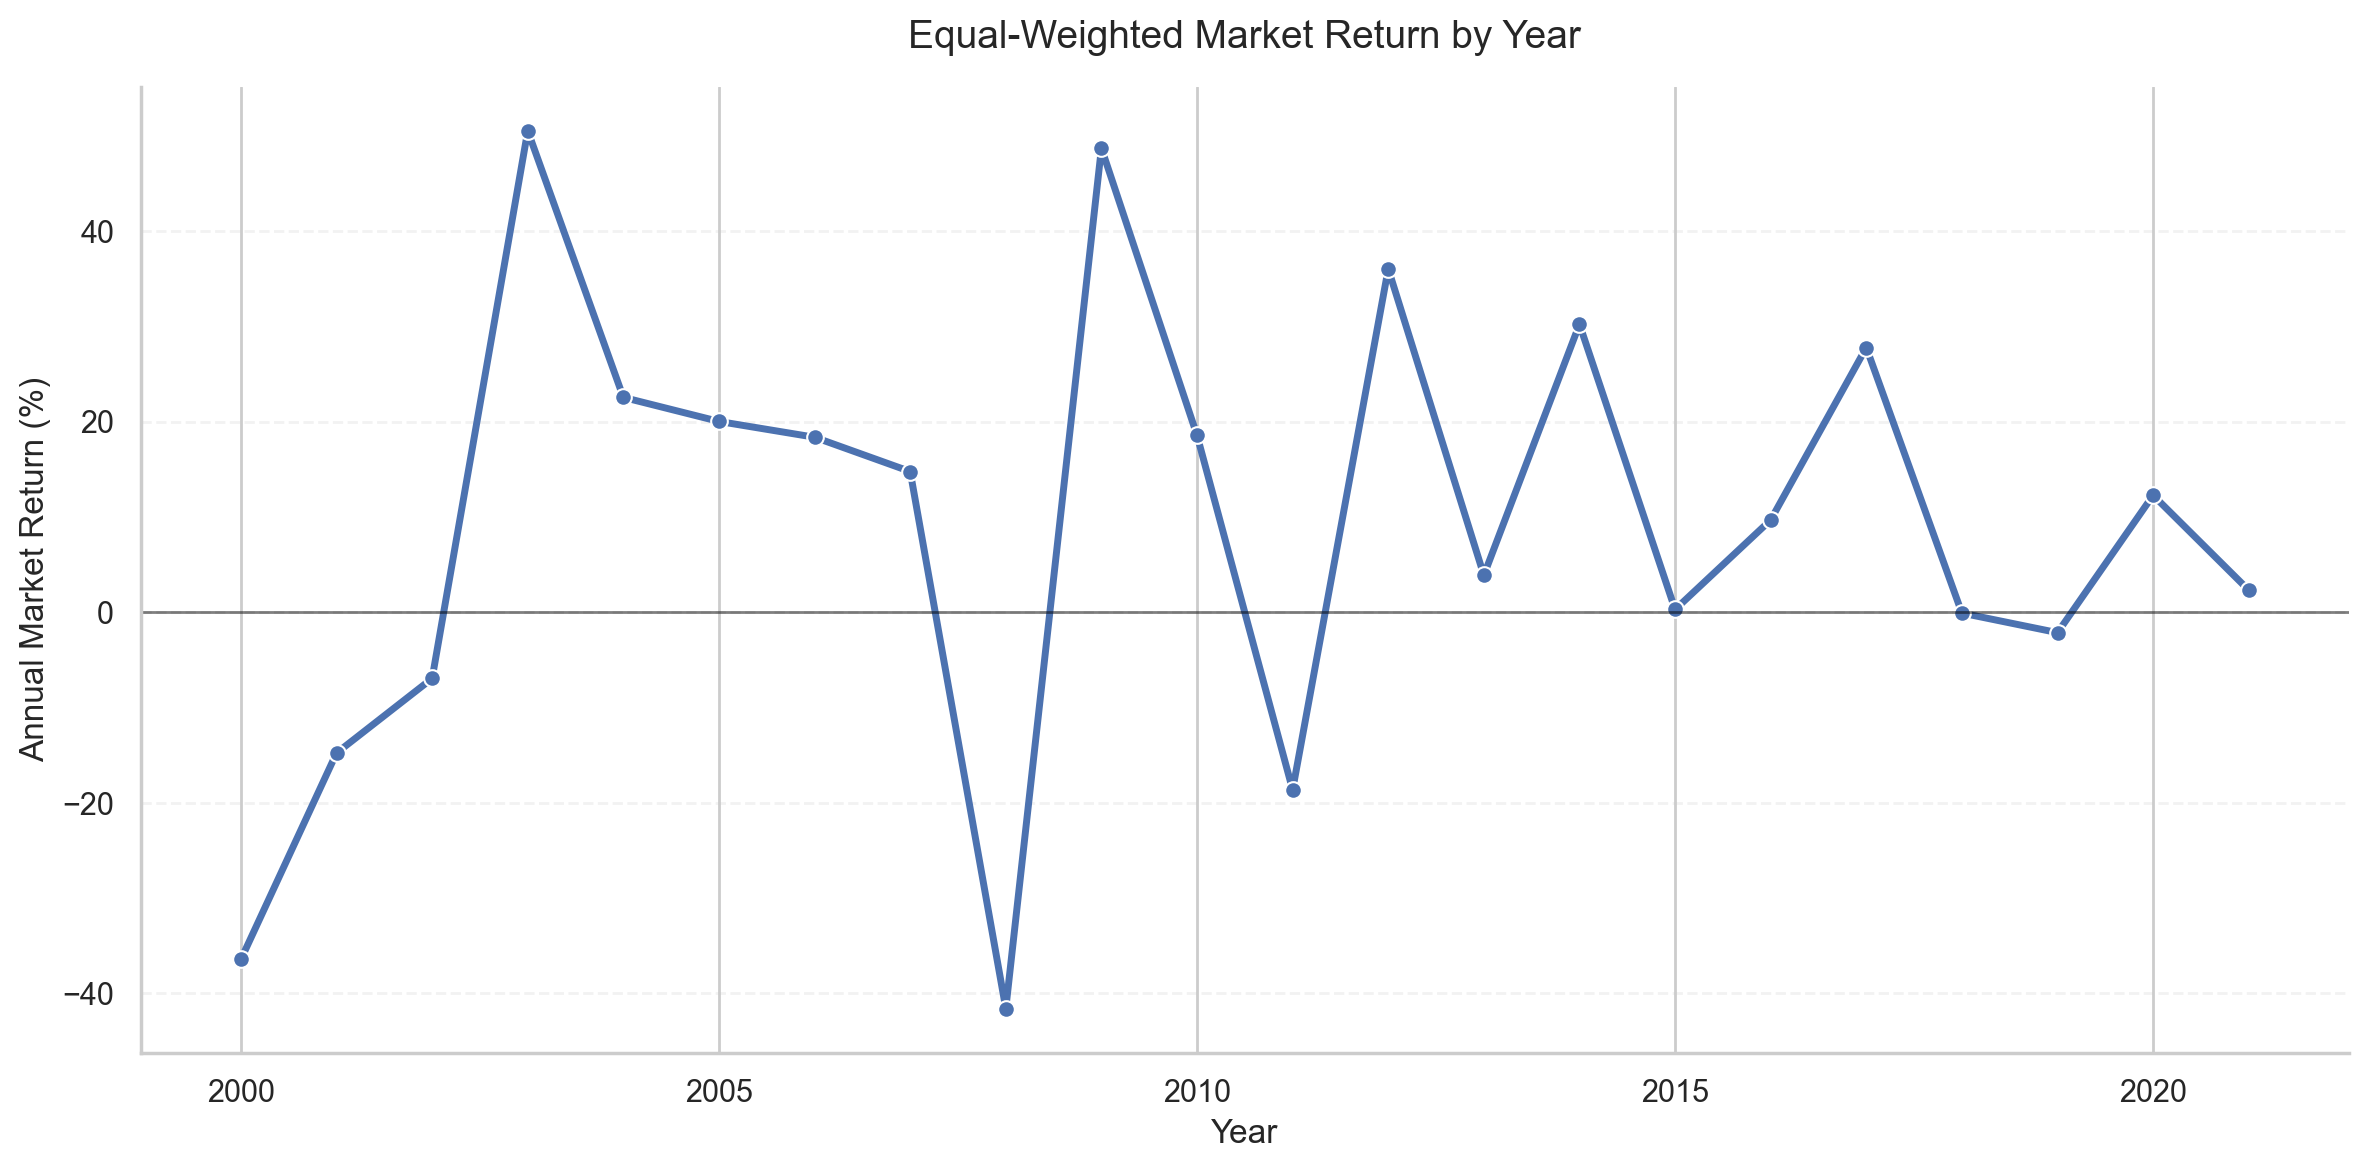

In [5]:
yearly_market_summary = artifacts["yearly_market_summary"]
display(
    yearly_market_summary[
        [
            "year",
            "cumulative_return_percent",
            "volatility_percent",
            "average_turnover_cr",
            "average_delivery_percent",
        ]
    ]
)
display(Image(filename=str(chart_paths["yearly_market_trend"])))


## Top and Bottom Stocks by Cumulative Return

This view highlights long-run winners and laggards at the stable company-file level. It is useful for dashboard ranking, shortlist filters, and explaining which names drove the strongest wealth creation versus the weakest holding outcomes.


,symbol,company_name,industry,cumulative_return_percent,annualized_return_percent,volatility_percent,max_drawdown_percent
0,RELIANCE,Reliance Industries Ltd.,ENERGY,"2,783.78",18.12,26.17,-45.35
1,TCS,Tata Consultancy Services Ltd.,IT,"1,907.21",21.15,23.28,-51.89
2,MARUTI,Maruti Suzuki India Ltd.,AUTOMOBILE,"1,739.28",19.10,26.23,-46.82
3,HCLTECH,HCL Technologies Ltd.,IT,"1,738.70",16.04,31.29,-61.24
4,MM,Mahindra & Mahindra Ltd.,AUTOMOBILE,"1,648.86",15.41,29.67,-67.38
9,ADANIPORTS,Adani Ports and Special Economic Zone Ltd.,SERVICES,-44.55,-4.58,33.18,-86.90
8,IOC,Indian Oil Corporation Ltd.,ENERGY,-48.97,-3.31,27.21,-78.49
7,ZEEL,Zee Entertainment Enterprises Ltd.,MEDIA & ENTERTAINMENT,-52.65,-3.70,37.35,-86.13
6,EICHERMOT,Eicher Motors Ltd.,AUTOMOBILE,-54.12,-3.88,30.05,-94.10
5,COALINDIA,Coal India Ltd.,METALS,-70.53,-11.54,24.55,-75.00


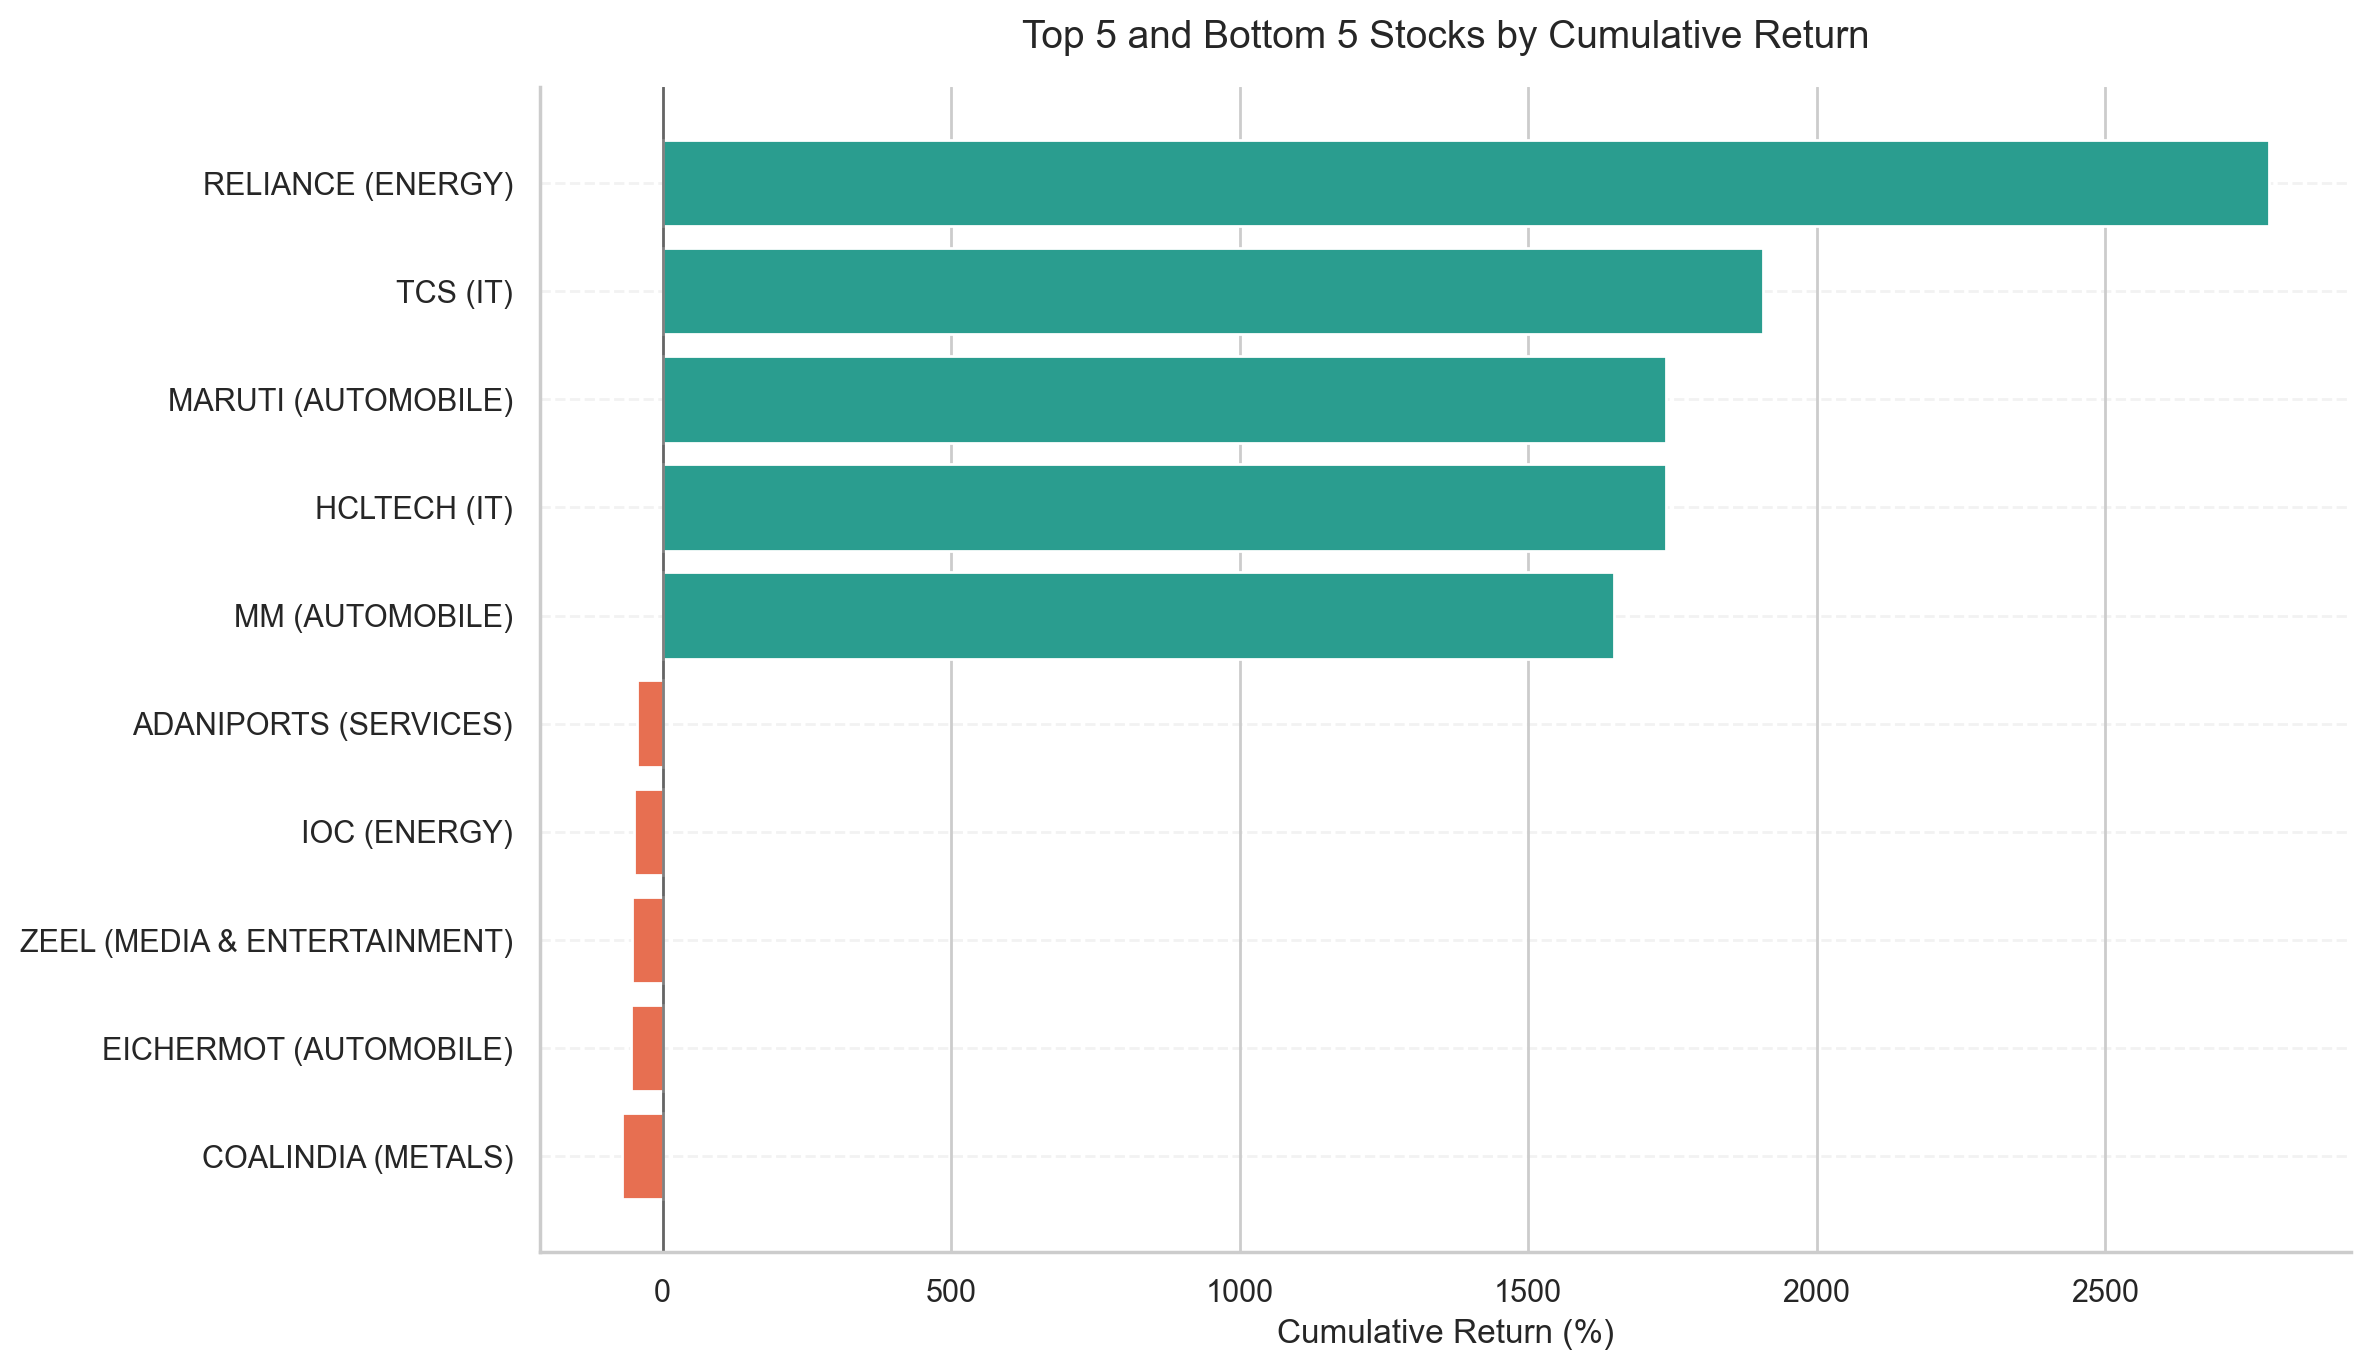

In [6]:
top_bottom_stocks = artifacts["top_bottom_stocks"].sort_values("cumulative_return_percent", ascending=False)
display(
    top_bottom_stocks[
        [
            "symbol",
            "company_name",
            "industry",
            "cumulative_return_percent",
            "annualized_return_percent",
            "volatility_percent",
            "max_drawdown_percent",
        ]
    ]
)
display(Image(filename=str(chart_paths["top_10_stocks_return"])))


## Sector Return and Volatility

Sector returns are built from equal-weighted daily stock returns inside each industry. Looking at return and volatility together shows which sectors rewarded investors without needing a separate dashboard view for raw price charts.


,industry,average_annual_return_percent,annualized_return_percent,volatility_percent,average_delivery_percent,opportunity_score
0,CEMENT & CEMENT PRODUCTS,20.90,16.69,22.58,59.65,82.69
7,METALS,19.83,8.07,28.13,36.98,54.23
2,IT,14.85,11.13,23.45,48.10,77.31
3,AUTOMOBILE,13.06,8.41,20.62,47.47,75.77
4,FINANCIAL SERVICES,11.00,6.88,19.78,51.15,70.77
1,PHARMA,9.72,8.17,18.64,52.98,78.27
9,CONSTRUCTION,9.20,4.39,26.31,47.46,32.50
5,ENERGY,8.89,6.40,18.77,50.23,64.23
8,FERTILISERS & PESTICIDES,8.54,6.04,32.31,55.85,39.62
6,CONSUMER GOODS,7.14,5.34,14.01,57.80,63.46


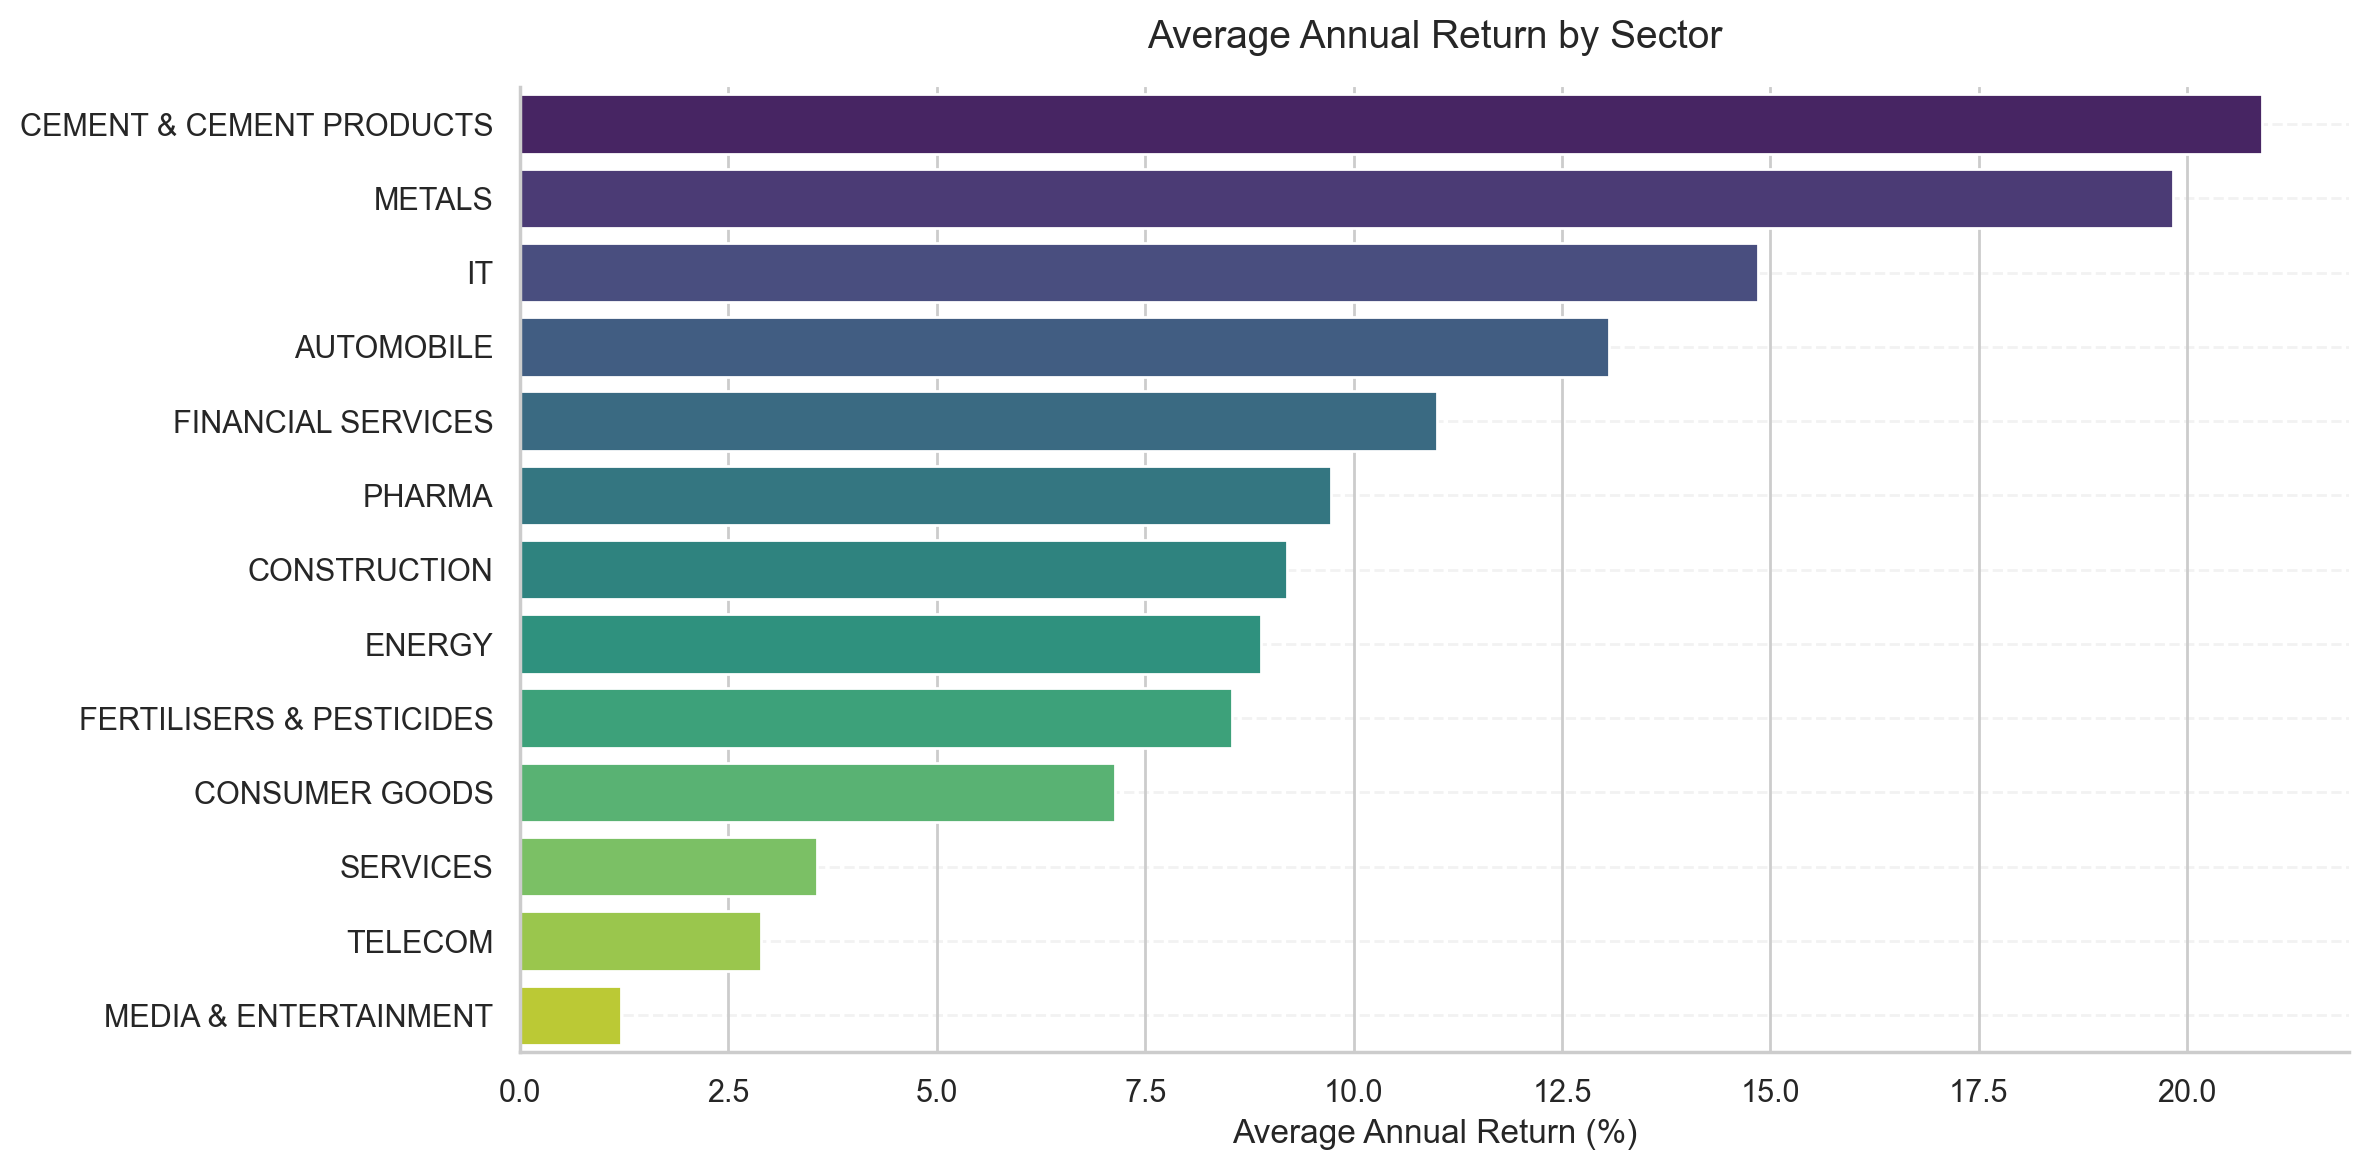

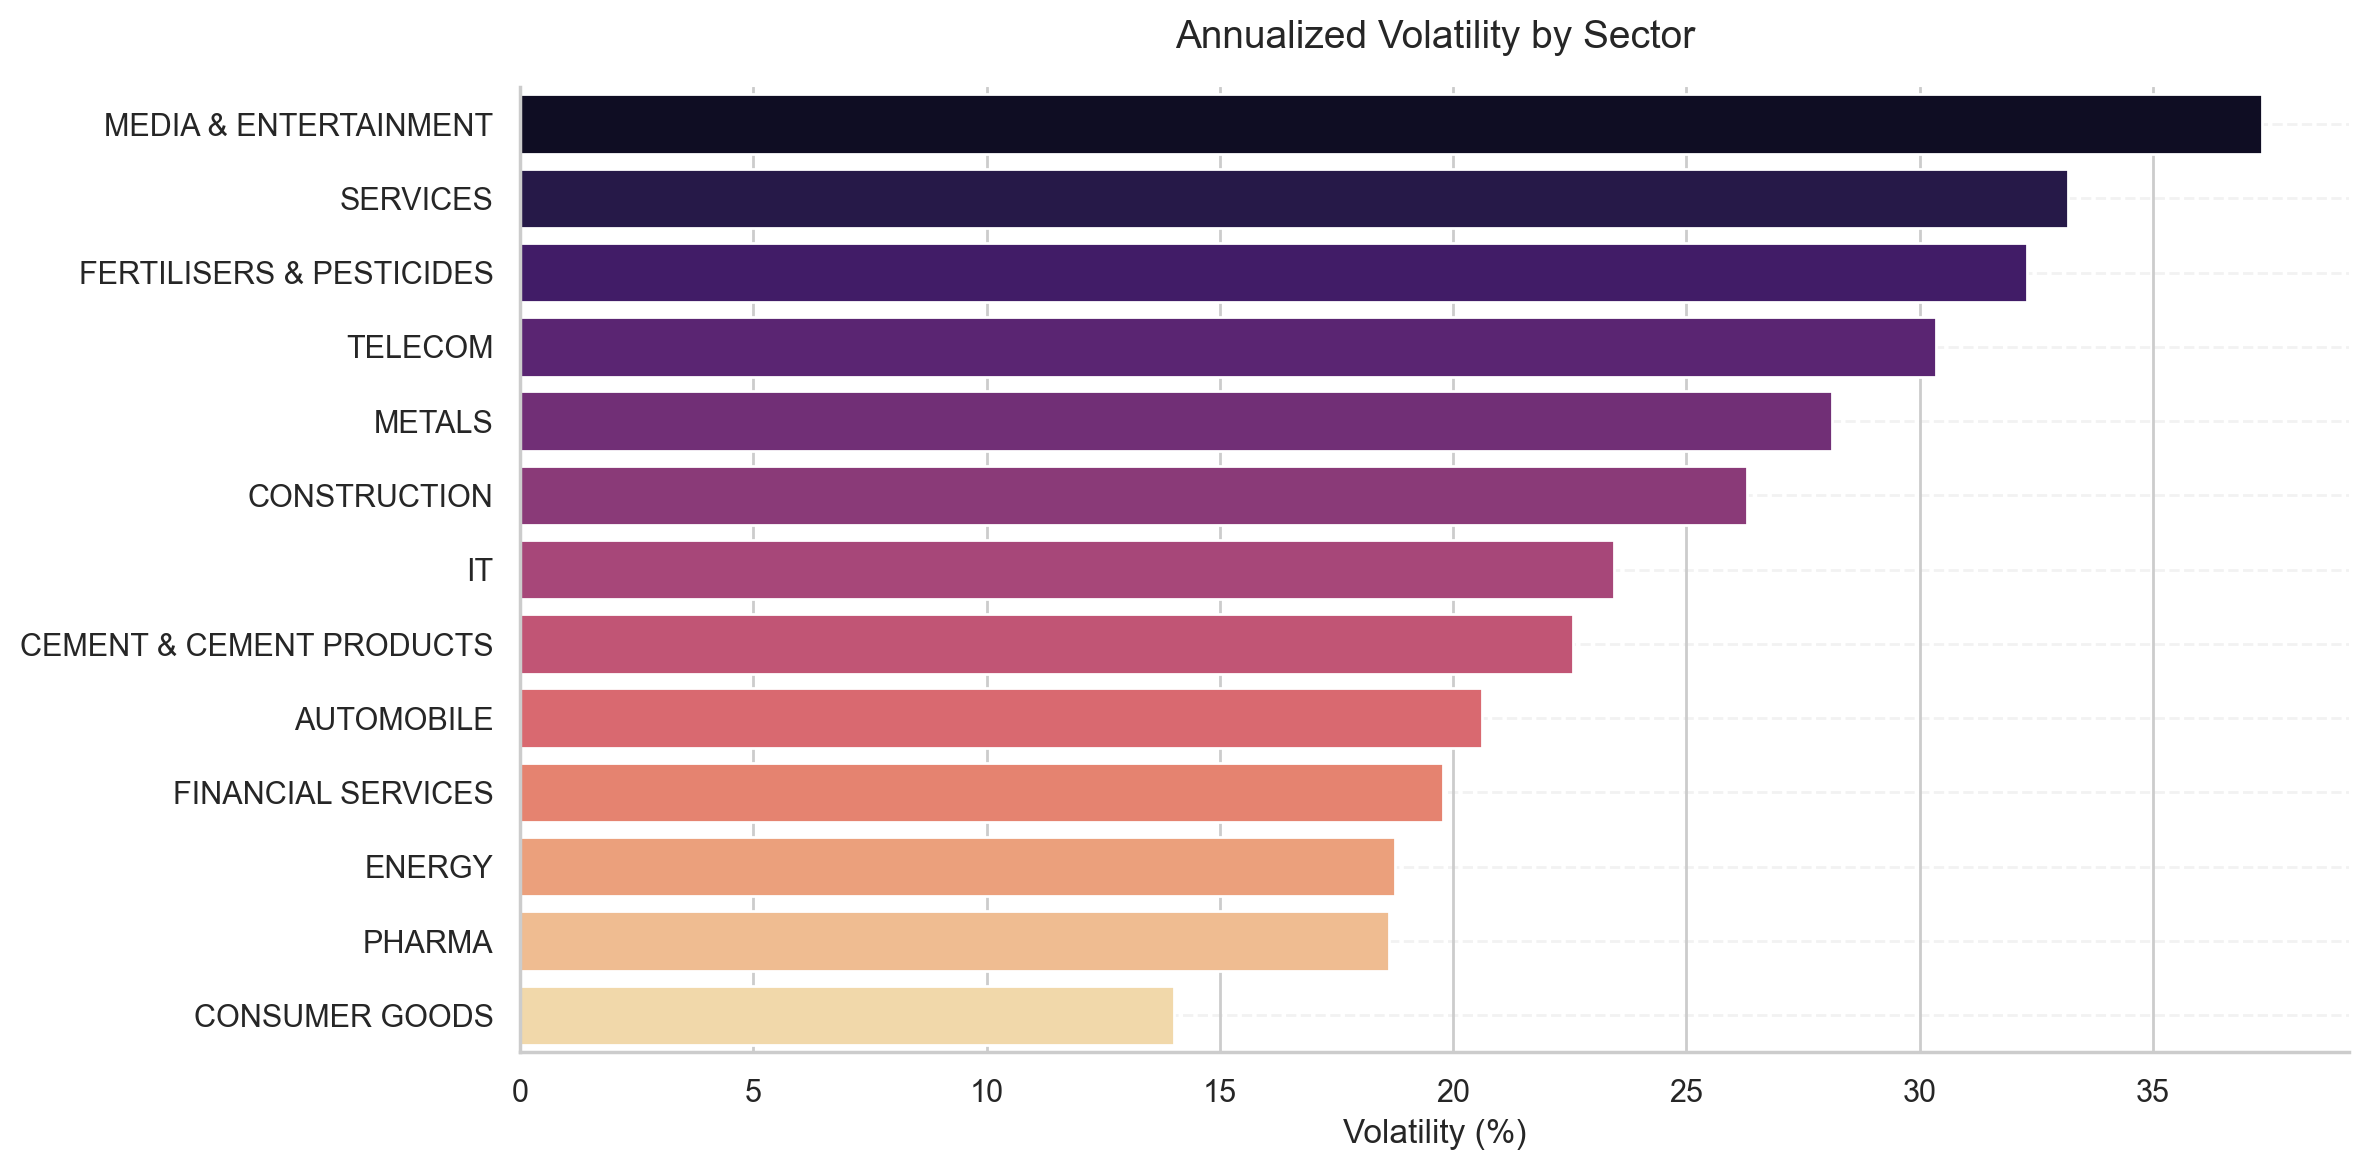

In [7]:
sector_kpis = artifacts["sector_kpis"].sort_values("average_annual_return_percent", ascending=False)
display(
    sector_kpis[
        [
            "industry",
            "average_annual_return_percent",
            "annualized_return_percent",
            "volatility_percent",
            "average_delivery_percent",
            "opportunity_score",
        ]
    ]
)
display(Image(filename=str(chart_paths["sector_return_comparison"])))
display(Image(filename=str(chart_paths["sector_volatility_comparison"])))


## Volume, Turnover, and Liquidity

Liquidity matters because attractive returns are harder to act on when trading depth is weak. The yearly trend below shows how trading activity expanded over time, while the stock KPI table turns volume and turnover into a comparable liquidity score.


,symbol,industry,average_volume,average_turnover_cr,liquidity_score,opportunity_score
0,TCS,IT,"1,676,761.95",295.21,66.33,91.73
1,RELIANCE,ENERGY,"5,583,027.54",607.67,89.80,84.80
2,ASIANPAINT,CONSUMER GOODS,"509,672.09",69.43,18.37,80.61
3,HDFC,FINANCIAL SERVICES,"1,848,186.92",262.08,63.27,79.69
4,BAJAJ-AUTO,AUTOMOBILE,"411,463.92",96.44,24.49,79.64
5,HDFCBANK,FINANCIAL SERVICES,"2,102,579.52",244.88,66.33,79.03
6,MARUTI,AUTOMOBILE,"1,194,660.80",239.53,53.06,77.76
7,HCLTECH,IT,"1,645,120.72",107.52,42.86,74.80
8,INFY,IT,"2,622,812.97",385.58,78.57,74.59
9,ITC,CONSUMER GOODS,"7,173,165.02",179.94,82.65,74.39


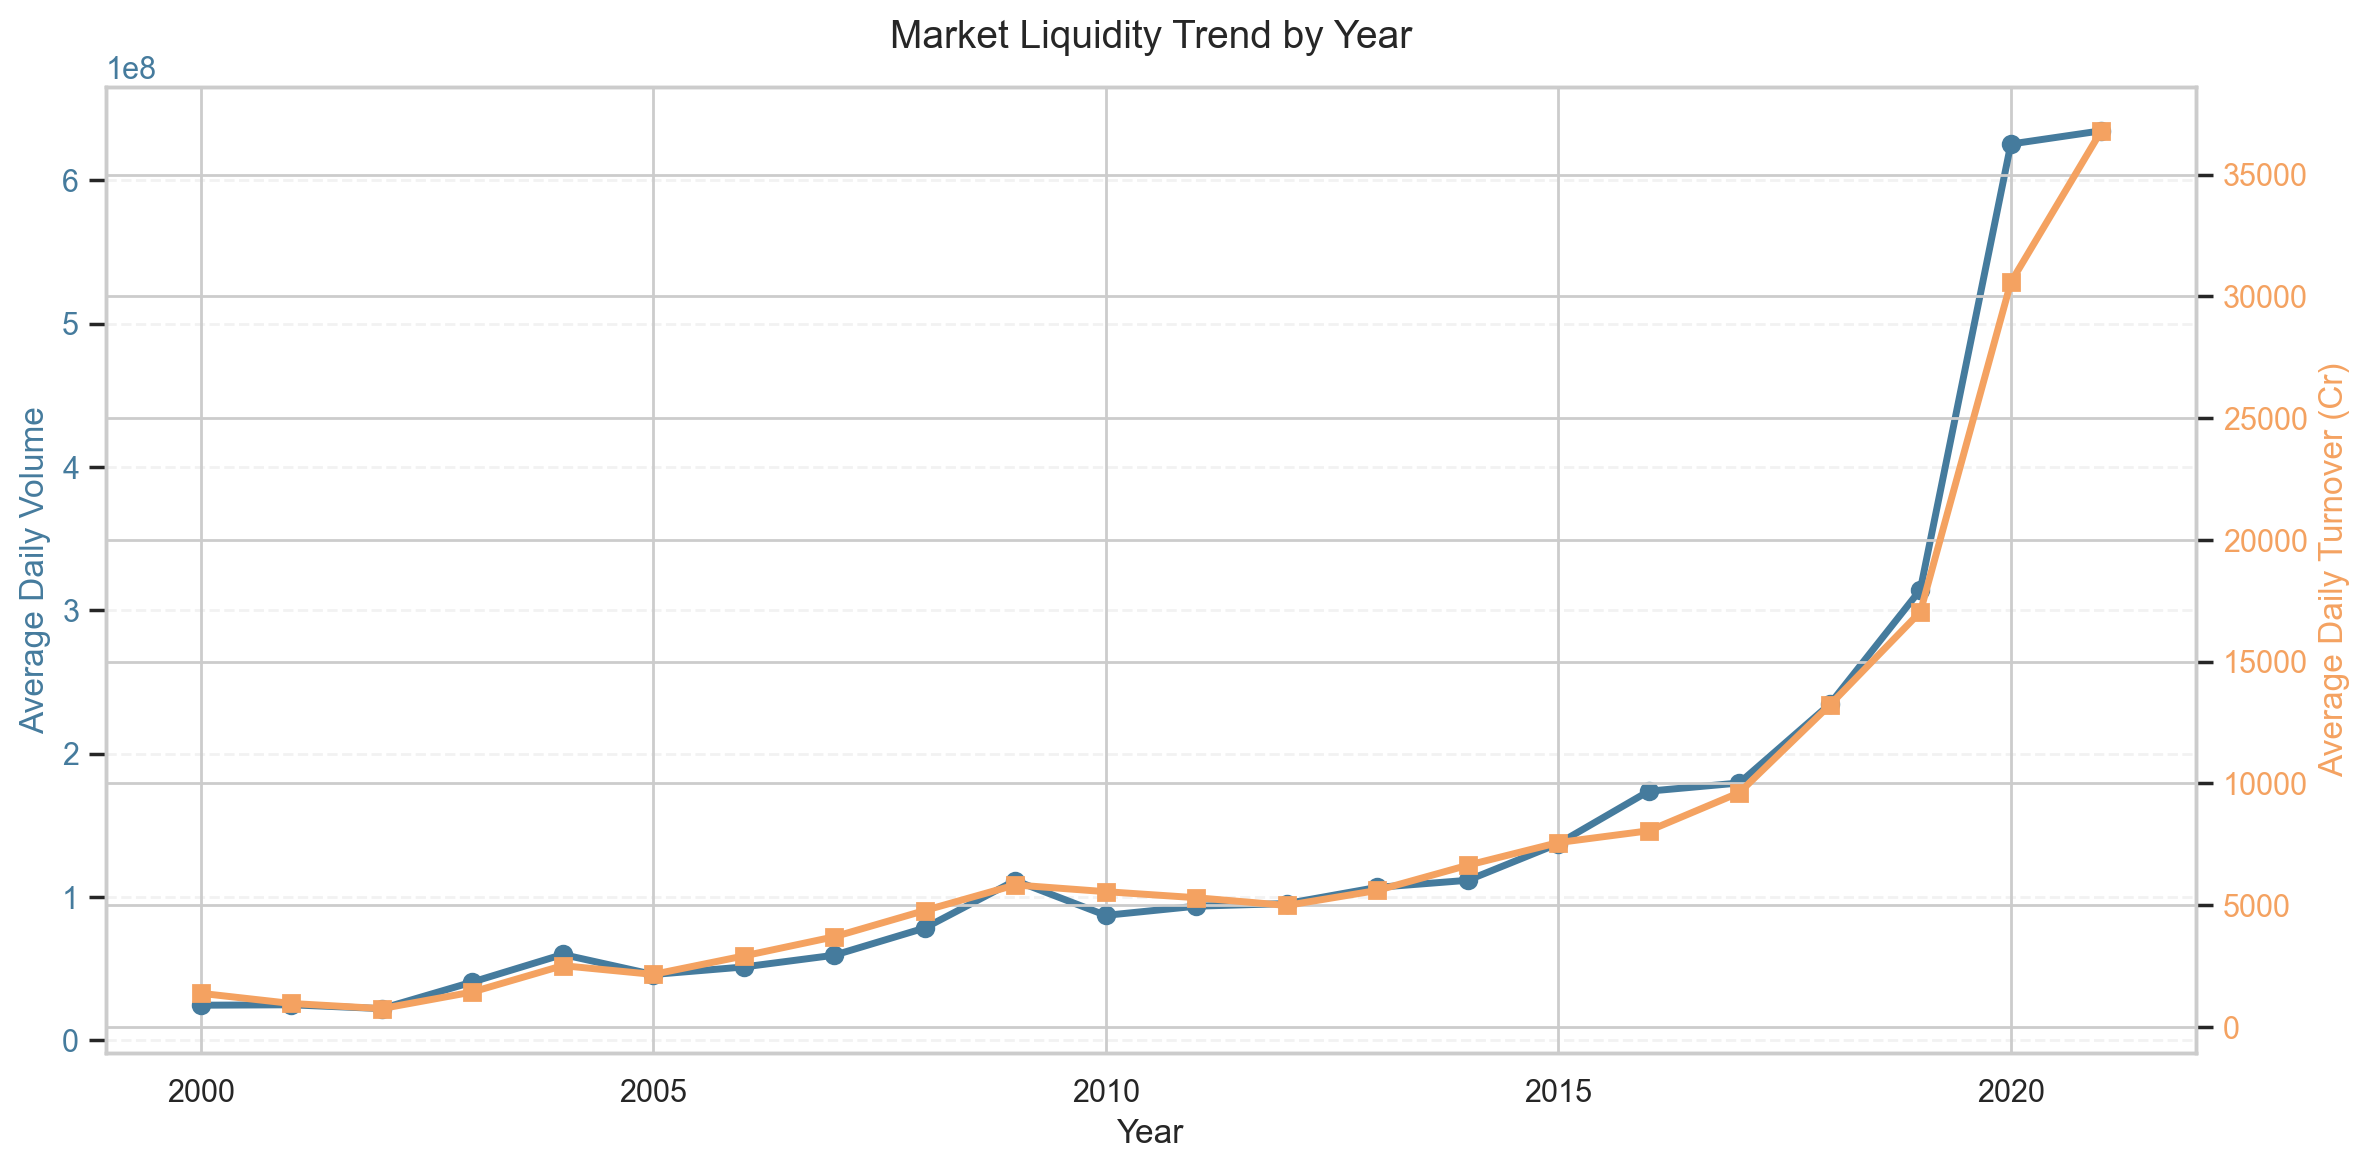

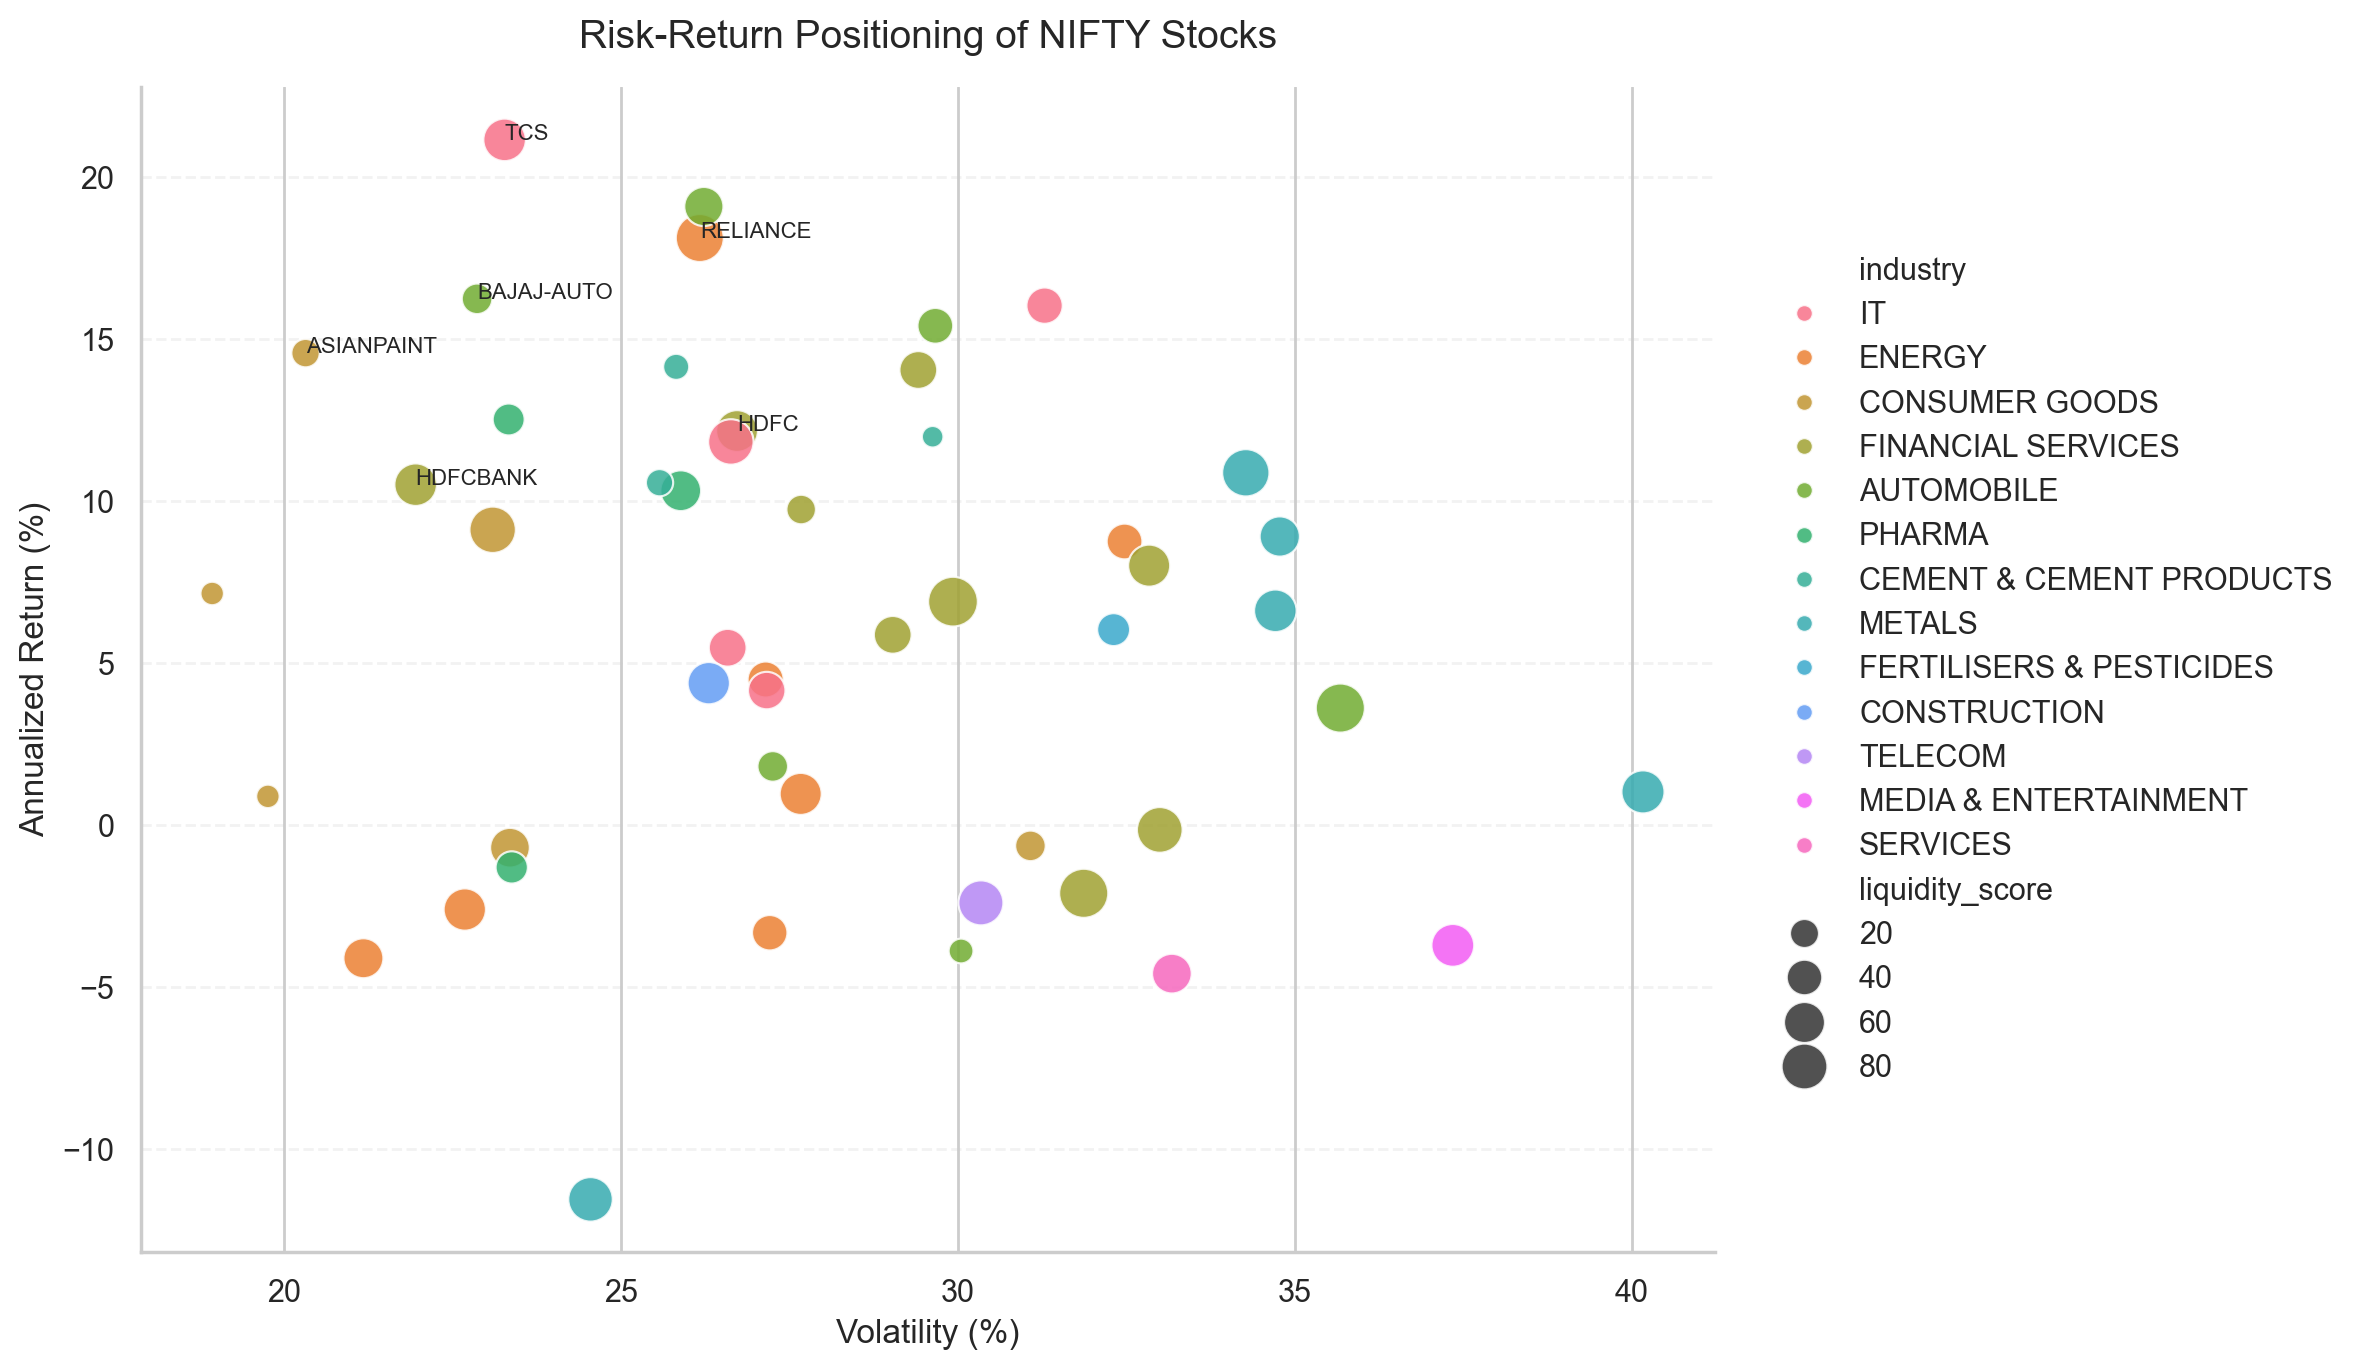

In [8]:
stock_kpis = artifacts["stock_kpis"]
display(
    stock_kpis[
        [
            "symbol",
            "industry",
            "average_volume",
            "average_turnover_cr",
            "liquidity_score",
            "opportunity_score",
        ]
    ].head(10)
)
display(Image(filename=str(chart_paths["volume_turnover_trend"])))
display(Image(filename=str(chart_paths["risk_return_scatter"])))


## VWAP Gap and Delivery Strength

VWAP gap acts as a simple execution-quality proxy: positive values mean the close finished above the session VWAP, while negative values suggest the market closed below the average traded level. Delivery percentage adds a conviction lens by showing how much volume translated into delivery-oriented participation.


,symbol,average_vwap_gap,close_above_vwap_ratio
0,SHREECEM,0.73,0.48
1,HDFC,0.41,0.52
2,HDFCBANK,0.40,0.51
3,BHARTIARTL,-0.02,0.45
4,POWERGRID,-0.04,0.47
5,HINDUNILVR,-0.06,0.50
6,NTPC,-0.09,0.45
7,ICICIBANK,-0.13,0.47
8,COALINDIA,-0.14,0.46
9,KOTAKBANK,-0.16,0.46


,symbol,average_vwap_gap,close_above_vwap_ratio
39,ULTRACEMCO,-1.03,0.47
40,VEDL,-1.07,0.42
41,BRITANNIA,-1.14,0.45
42,LT,-1.15,0.44
43,DRREDDY,-1.24,0.45
44,TECHM,-1.38,0.40
45,MARUTI,-1.48,0.45
46,NESTLEIND,-2.28,0.46
47,BAJAJFINSV,-2.50,0.37
48,EICHERMOT,-3.12,0.44


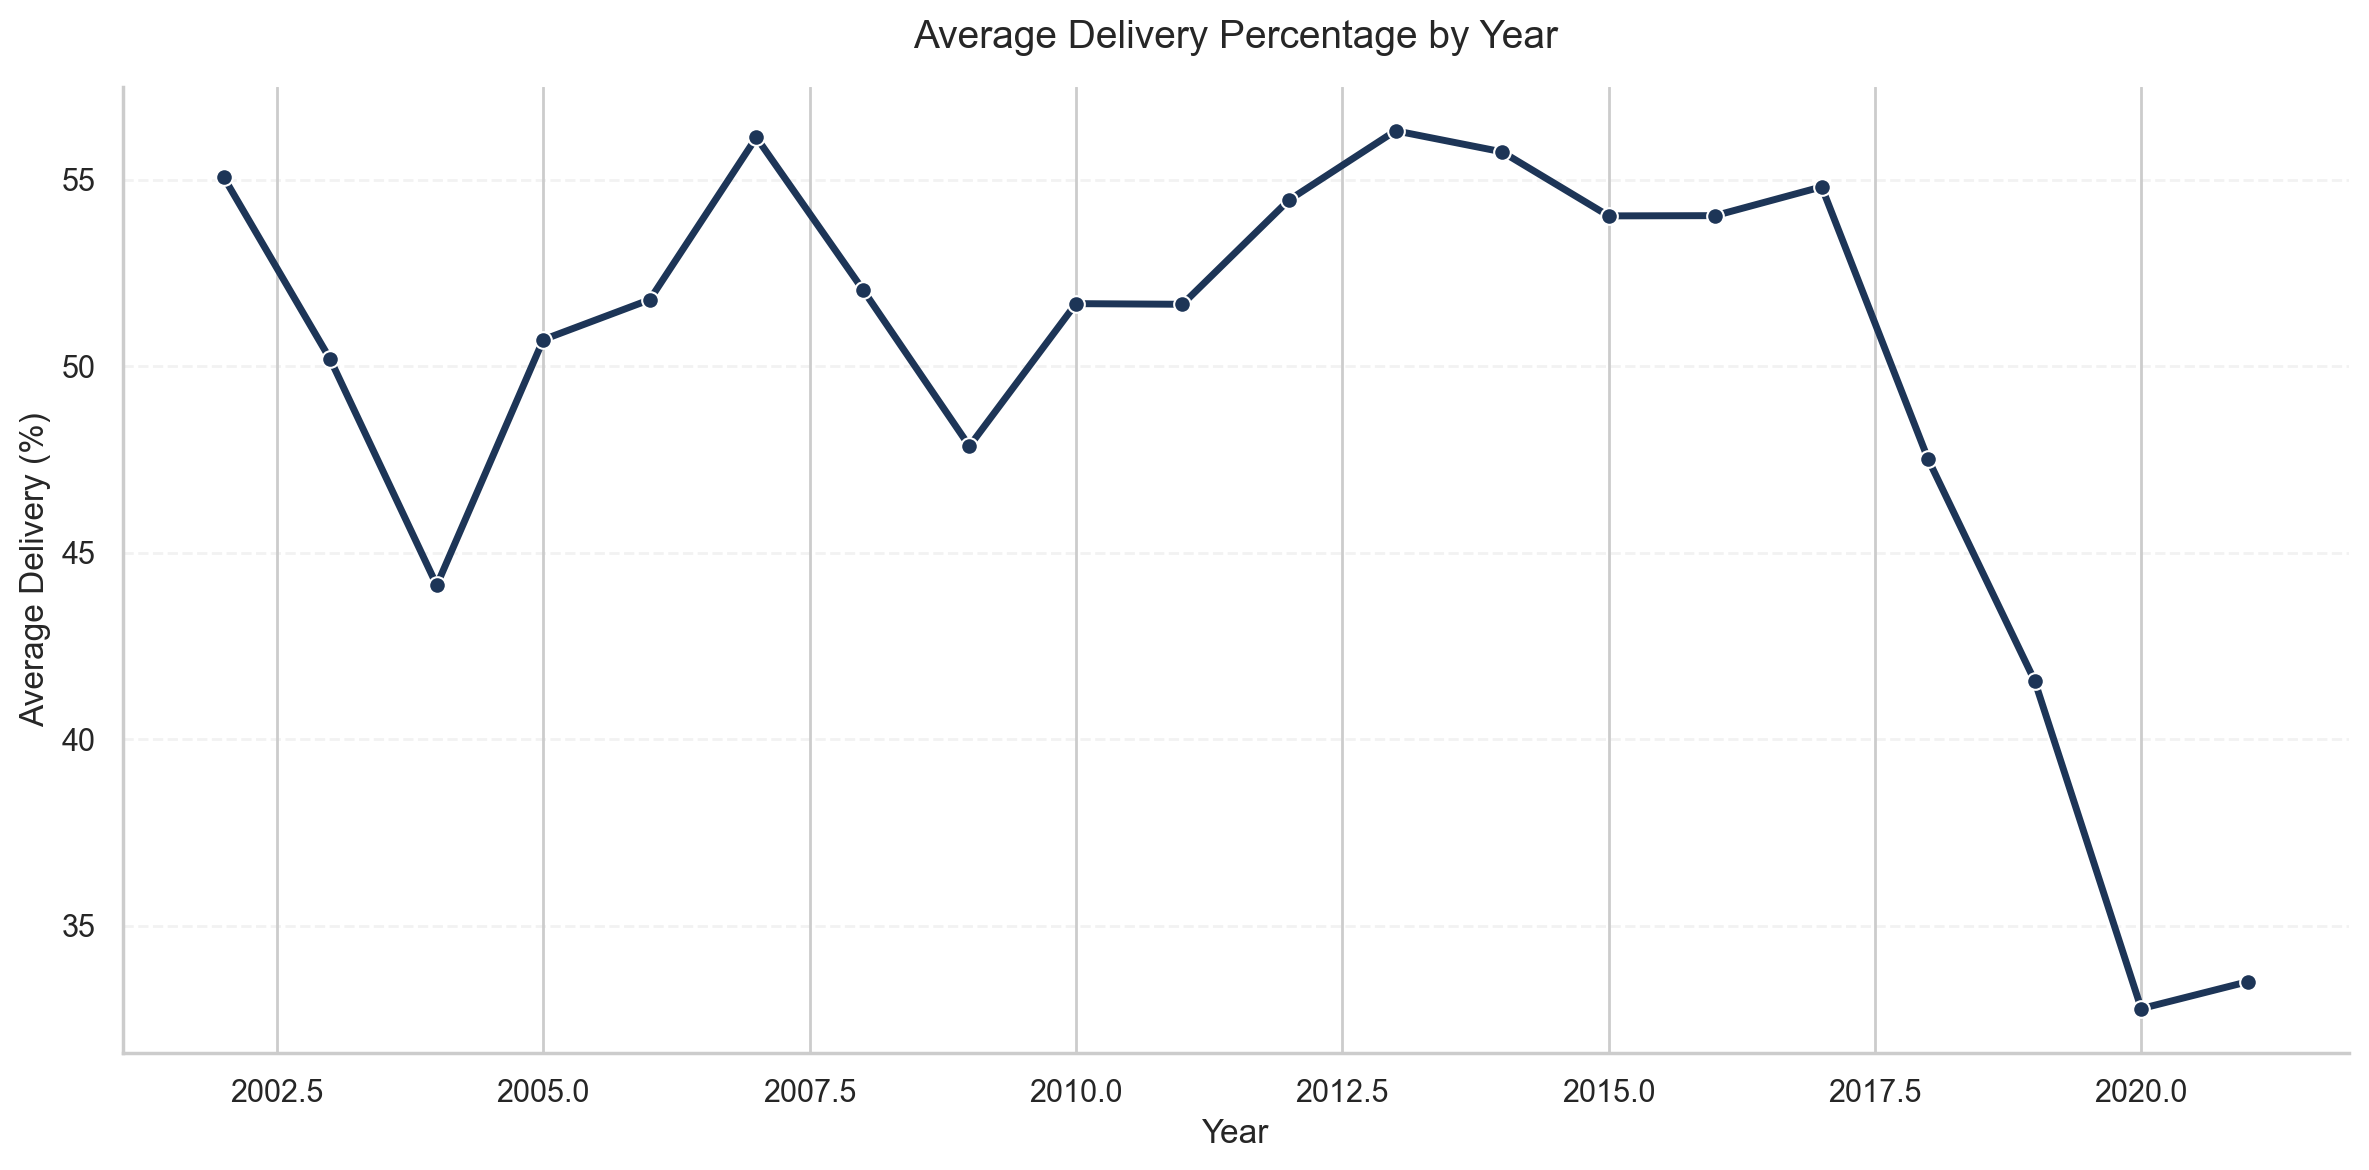

In [9]:
vwap_summary = artifacts["vwap_summary"]
correlation_table = artifacts["correlation_table"]

display(vwap_summary.head(10))
display(vwap_summary.tail(10))
display(Image(filename=str(chart_paths["delivery_percent_trend"])))


## COVID-19 Crash and Recovery

The 2020 view is split into a pre-COVID baseline, the crash window from mid-February through March, and the April-to-December recovery period. This makes it easier to explain how returns, volatility, turnover, and delivery behavior changed under stress and during the rebound.


,period,start_date,end_date,trading_days,cumulative_return_percent,annualized_return_percent,volatility_percent,average_daily_return,max_drawdown_percent,risk_adjusted_return,average_volume,average_turnover_cr,average_delivery_percent,average_vwap_gap
0,Pre-COVID Baseline,2019-01-01,2020-02-14,279,-3.36,-3.04,12.47,-0.01,-15.25,-0.24,"321,068,112.84","17,196.87",41.20,-0.68
1,Crash Phase,2020-02-17,2020-03-31,30,-17.25,-79.61,24.82,-0.62,-19.50,-3.21,"660,916,069.77","26,892.55",42.03,-2.85
2,Recovery Phase,2020-04-01,2020-12-31,188,37.42,53.13,15.69,0.17,-9.11,3.39,"665,881,098.40","33,384.83",30.24,-0.79


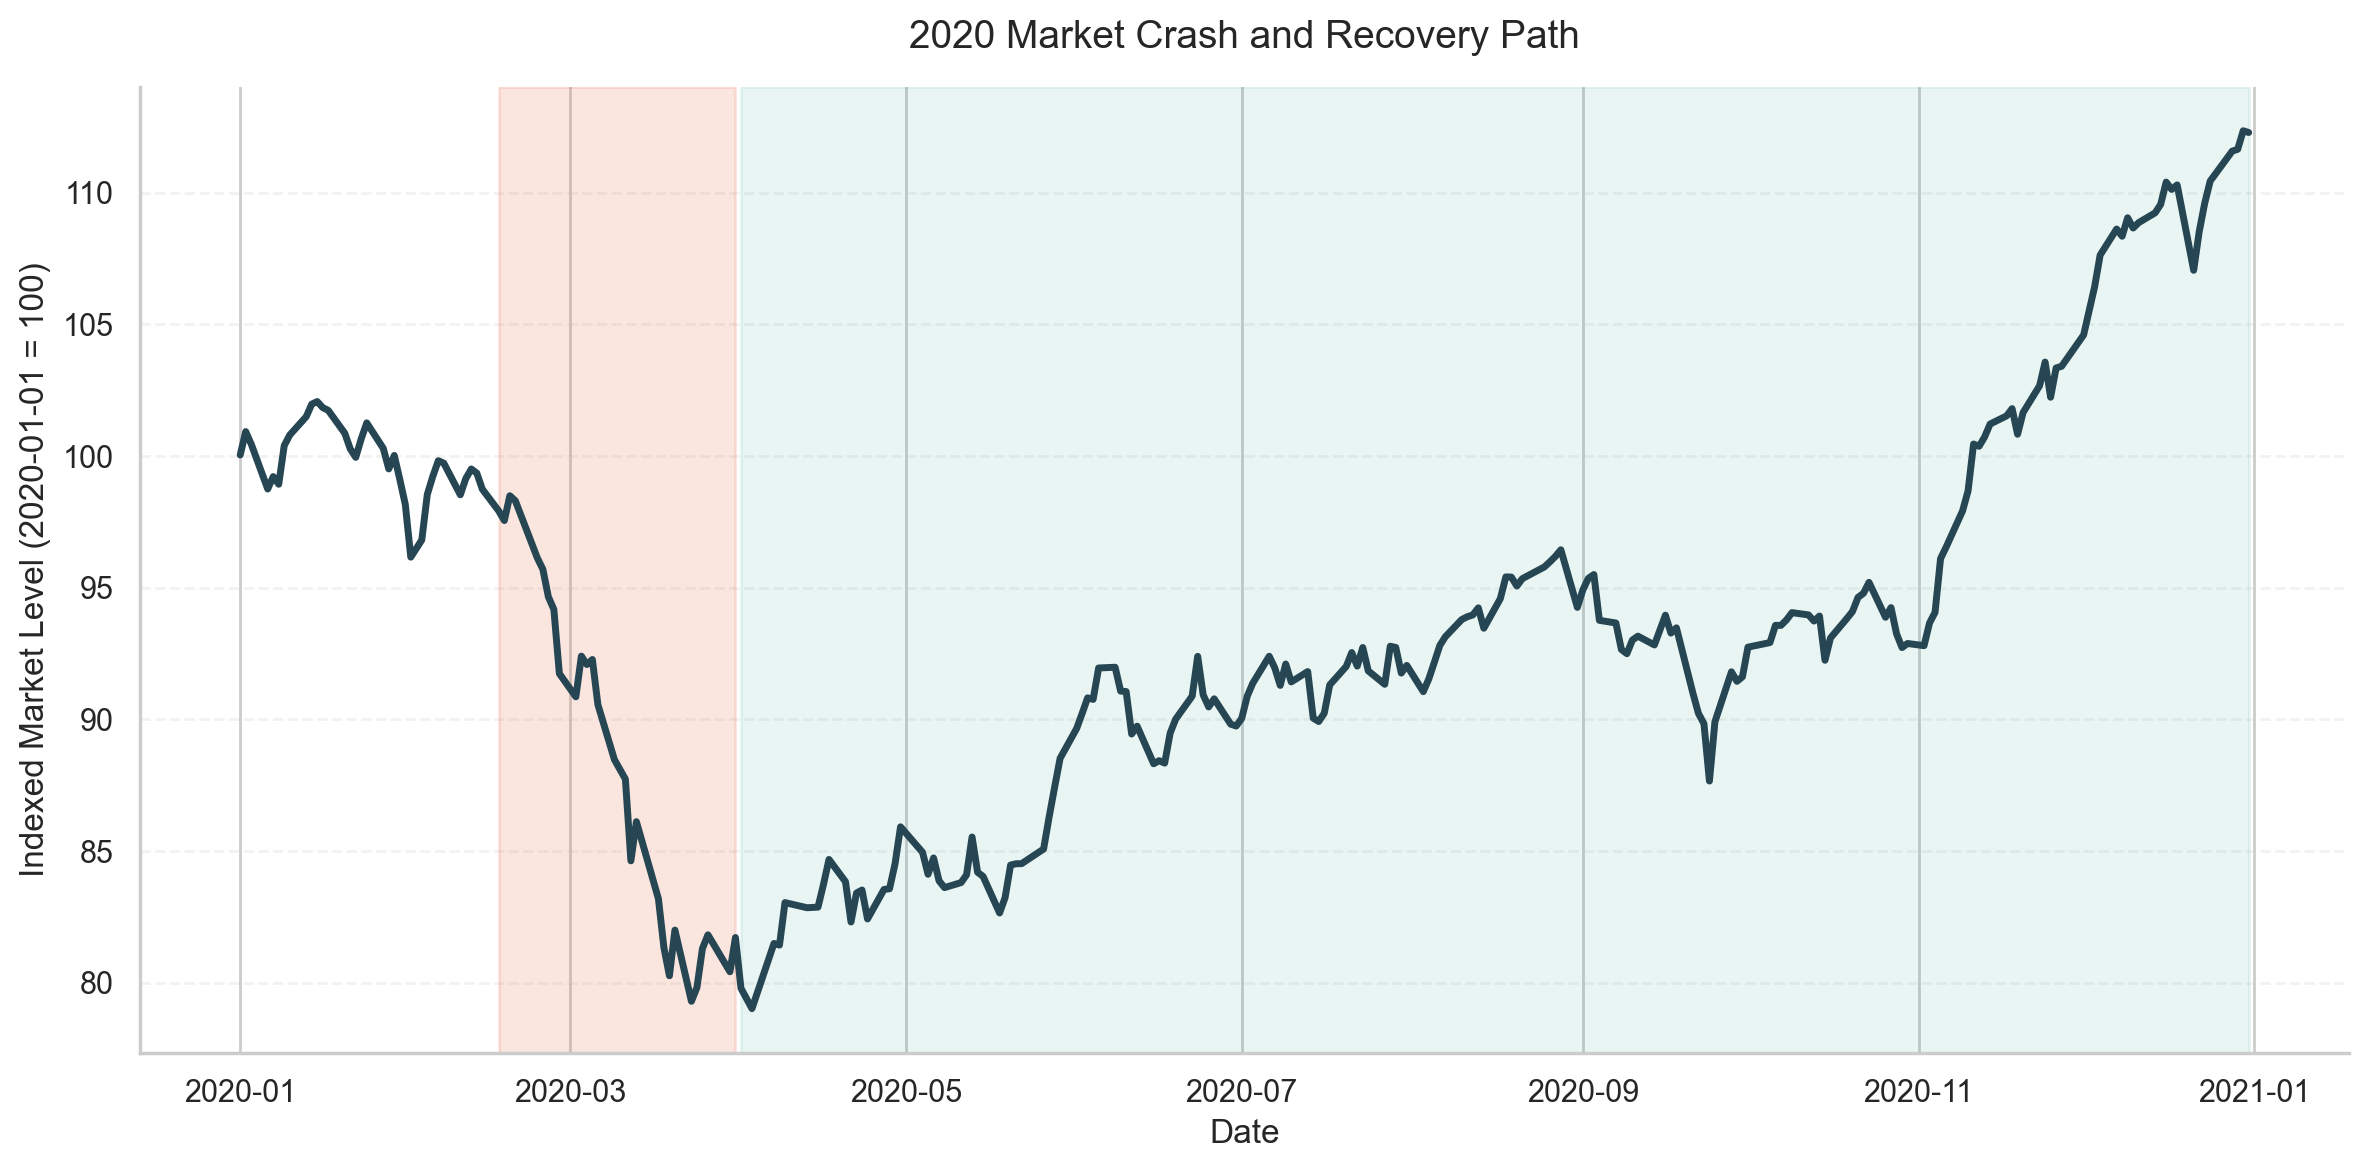

In [10]:
covid_period_summary = artifacts["covid_period_summary"]
display(covid_period_summary)
display(Image(filename=str(chart_paths["covid_crash_recovery"])))


## Correlation Check

This final check looks at simple linear relationships between returns and trading activity variables. It is meant to support exploratory filtering decisions in Tableau, not to claim causality.


In [11]:
display(correlation_table)


,daily_return,volume,turnover_cr,deliverable_percent,vwap_gap
daily_return,1.00,0.03,0.03,-0.04,0.27
volume,0.03,1.00,0.63,-0.21,0.01
turnover_cr,0.03,0.63,1.00,-0.19,0.01
deliverable_percent,-0.04,-0.21,-0.19,1.00,0.01
vwap_gap,0.27,0.01,0.01,0.01,1.00


## Output Files

The notebook writes Tableau-ready KPI tables to `outputs/tables/` and saves reusable chart assets to `outputs/charts/`. These paths are version-controlled outputs, so the dashboard and written report can reference the same evidence generated here.


In [12]:
pd.Series({name: str(path) for name, path in table_paths.items()}, name="table_path")


stock_kpis               /Users/abheydua2025/Desktop/dva-final/outputs/...
sector_kpis              /Users/abheydua2025/Desktop/dva-final/outputs/...
yearly_market_summary    /Users/abheydua2025/Desktop/dva-final/outputs/...
covid_period_summary     /Users/abheydua2025/Desktop/dva-final/outputs/...
Name: table_path, dtype: str